# 01 — CMOS Inverter

Demonstrates the two ways to use `gl`:
- **Functional** (one-off, no class needed)
- **Module** (reusable, parametric — like `nn.Module`)

Old glayout style needed ~40 lines of `c_route / straight_route / movex / add_ports`.  
With `gl` it is 8 lines, reads like a schematic.

In [1]:
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, os.path.abspath('../../src/gelochip'))

## Option A — Functional API

2026-05-20 16:27:00.170 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


[gl] reloaded — DRC sweep active (with_tie=True by default)
[gl.build] running DRC sweep for 'inverter'...


2026-05-20 16:27:05.453 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/_rl_tmp.gds'
2026-05-20 16:27:05.482 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/_RL_TMP.gds'


using provided pdk_root
Defaulting to stale magic_commands.tcl


2026-05-20 16:27:05.756 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpajdj7so7/_RL_TMP.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpn6xo7ffs/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "_RL_TMP".
[INFO]: Loading _RL_T

2026-05-20 16:27:08.121 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/inverter.gds'


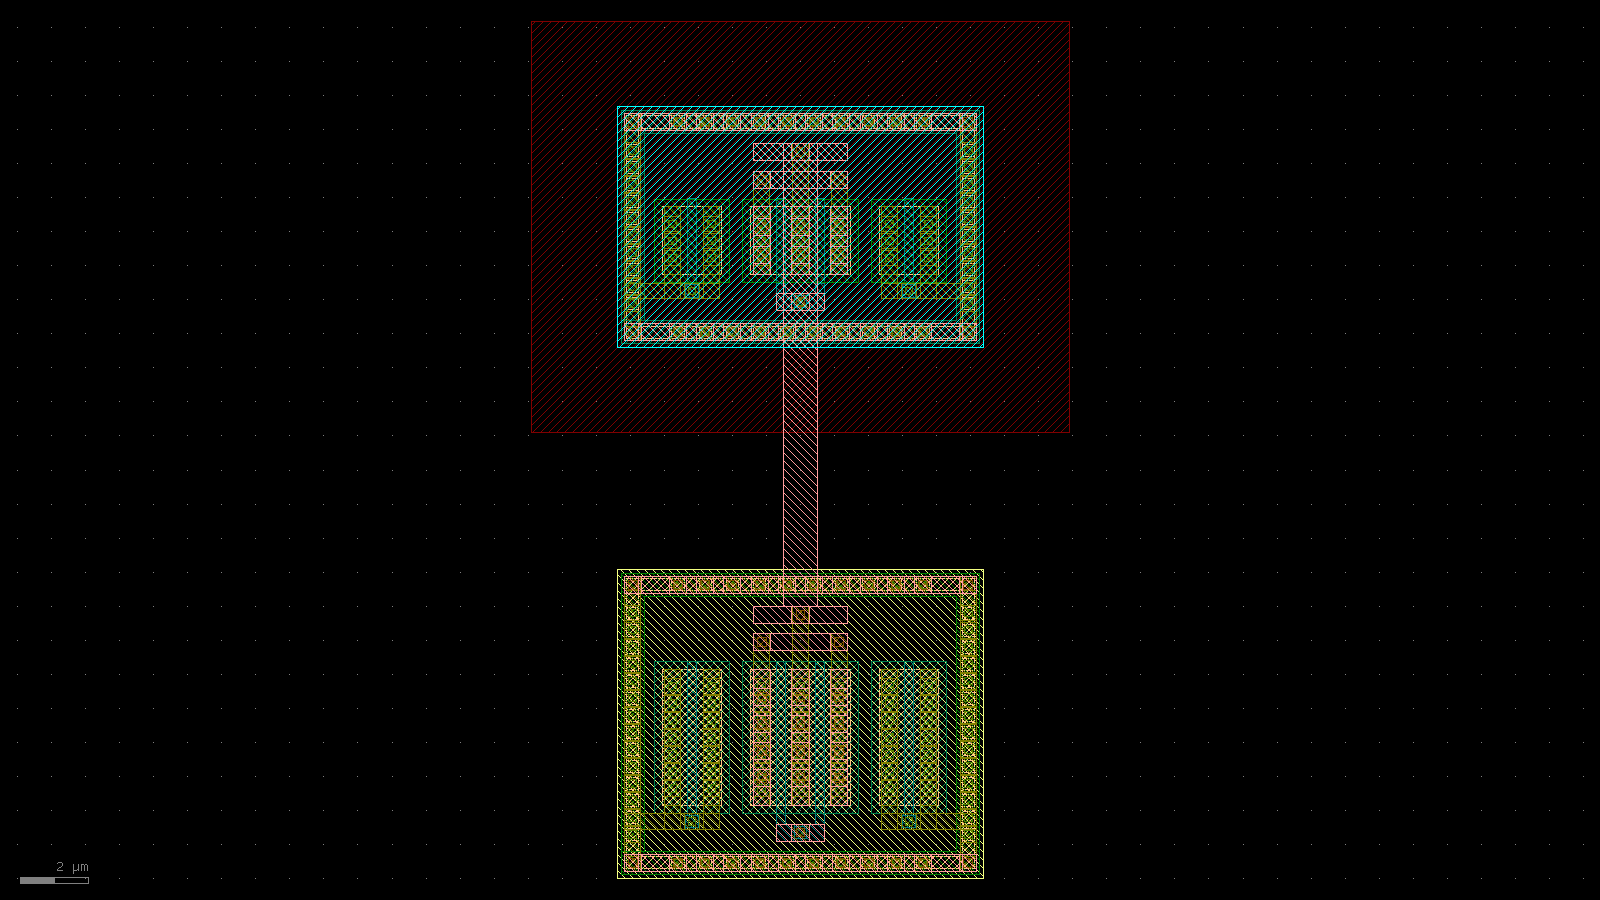

In [2]:
import gelochip.gl as gl
gl.reload()  # pick up latest code without restarting kernel

vin  = gl.Net('vin')
vout = gl.Net('vout')

mp = gl.pmos(w=4.0, fingers=2, g=vin, d=vout, s=gl.vdd)
mn = gl.nmos(w=2.0, fingers=2, g=vin, d=vout, s=gl.gnd)

chip = gl.build(mp, mn, name='inverter')
chip.show()

## Option B — Module style (like `nn.Module`)

2026-05-20 16:27:13.680 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/inverter.gds'


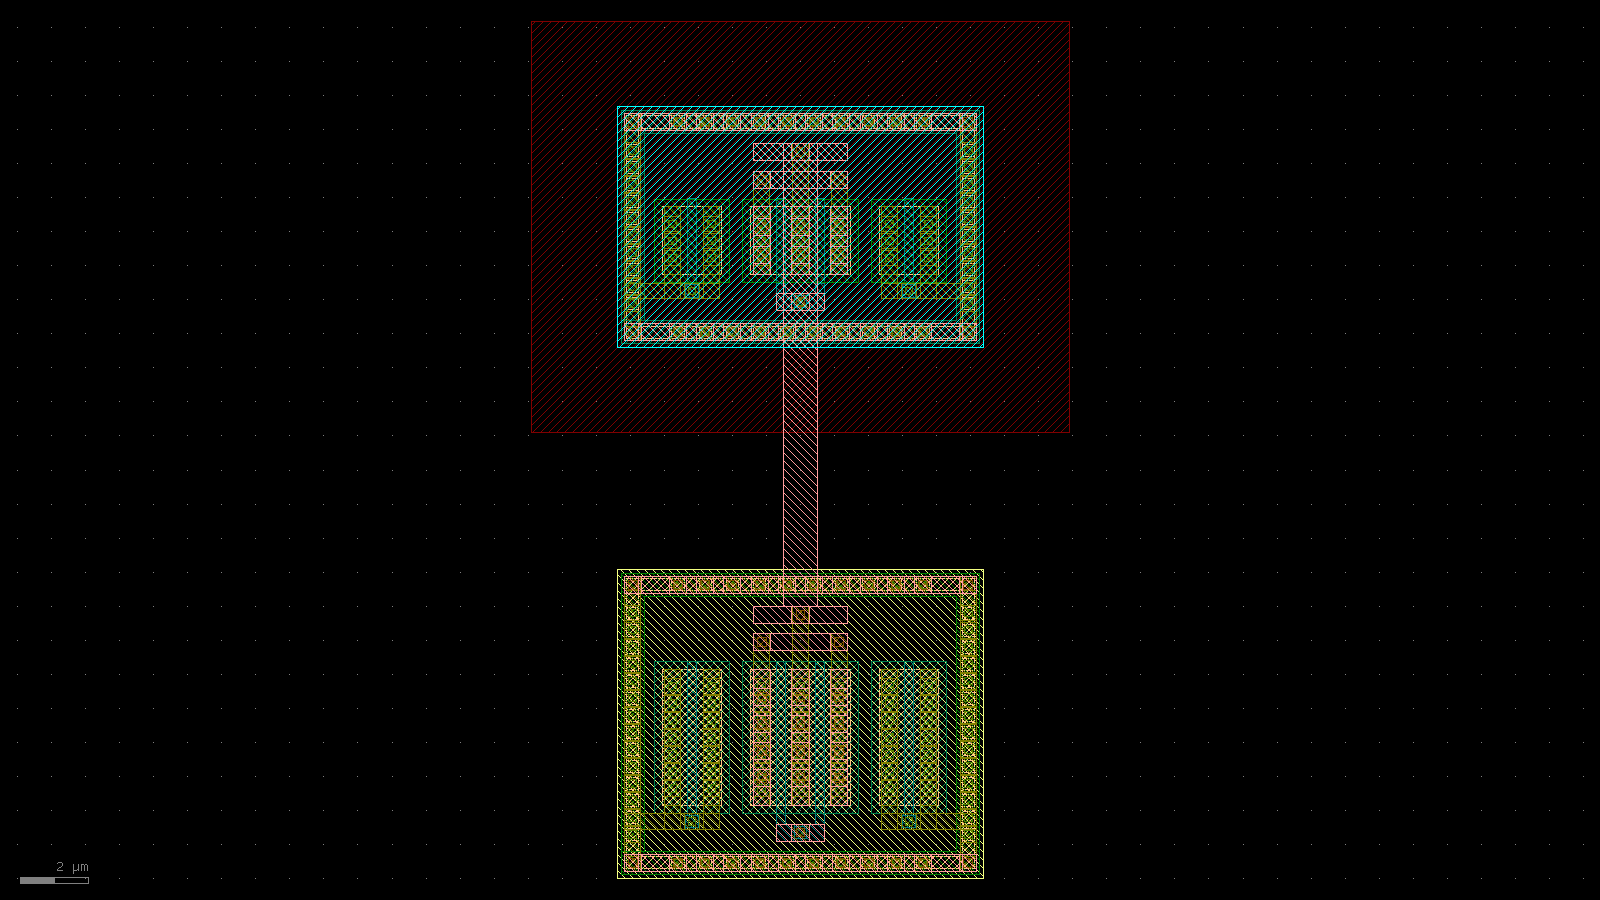

In [3]:
class Inverter(gl.Module):
    def __init__(self, wp=4.0, wn=2.0, fingers=2):
        super().__init__(gl.gf180)
        self.wp = wp
        self.wn = wn
        self.fingers = fingers

    def layout(self):
        vin  = self.pin('vin')
        vout = self.pin('vout')
        gl.pmos(w=self.wp, fingers=self.fingers, g=vin, d=vout, s=gl.vdd)
        gl.nmos(w=self.wn, fingers=self.fingers, g=vin, d=vout, s=gl.gnd)

chip = Inverter(wp=4, wn=2).build()
chip.show()

In [4]:
chip.drc()

2026-05-20 16:27:16.226 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/INVERTER.gds'


using provided pdk_root
Defaulting to stale magic_commands.tcl


2026-05-20 16:27:16.502 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp9_koo3i6/INVERTER.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpq8fkuxyt/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "INVERTER".
[INFO]: Loading INVE

{'status': 'pass',
 'is_pass': True,
 'report_path': '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/INVERTER_drc_out/drc/INVERTER/INVERTER.rpt',
 'total_errors': 0,
 'error_details': [],
 'NW': 0,
 'CO': 0,
 'PL': 0,
 'DF': 0,
 'other': 0}

In [4]:
chip.lvs()

2026-05-20 16:12:29.490 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/INVERTER.gds'


using provided pdk_root
Defaulting to stale magic_commands.tcl


2026-05-20 16:12:29.766 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp8yst8rzq/INVERTER.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpgmel4ic9/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "INVERTER".
[INFO]: Loading INVE

{'status': "error: 'netlist'",
 'is_pass': False,
 'report_path': '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/INVERTER_lvs_out/lvs/INVERTER/INVERTER_lvs.rpt',
 'summary': {}}

In [5]:
chip.sim()

[gl.sim] No netlist found in component.info for 'inverter'.


{'converged': False, 'error': 'no netlist'}

In [6]:
chip.save('inverter.gds')

2026-05-19 18:11:00.128 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'inverter.gds'


[gl] saved → inverter.gds


## Parametric sweep — trivial with Python classes

2026-05-20 16:12:40.862 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/inv_wp2.gds'


wp=2 wn=1


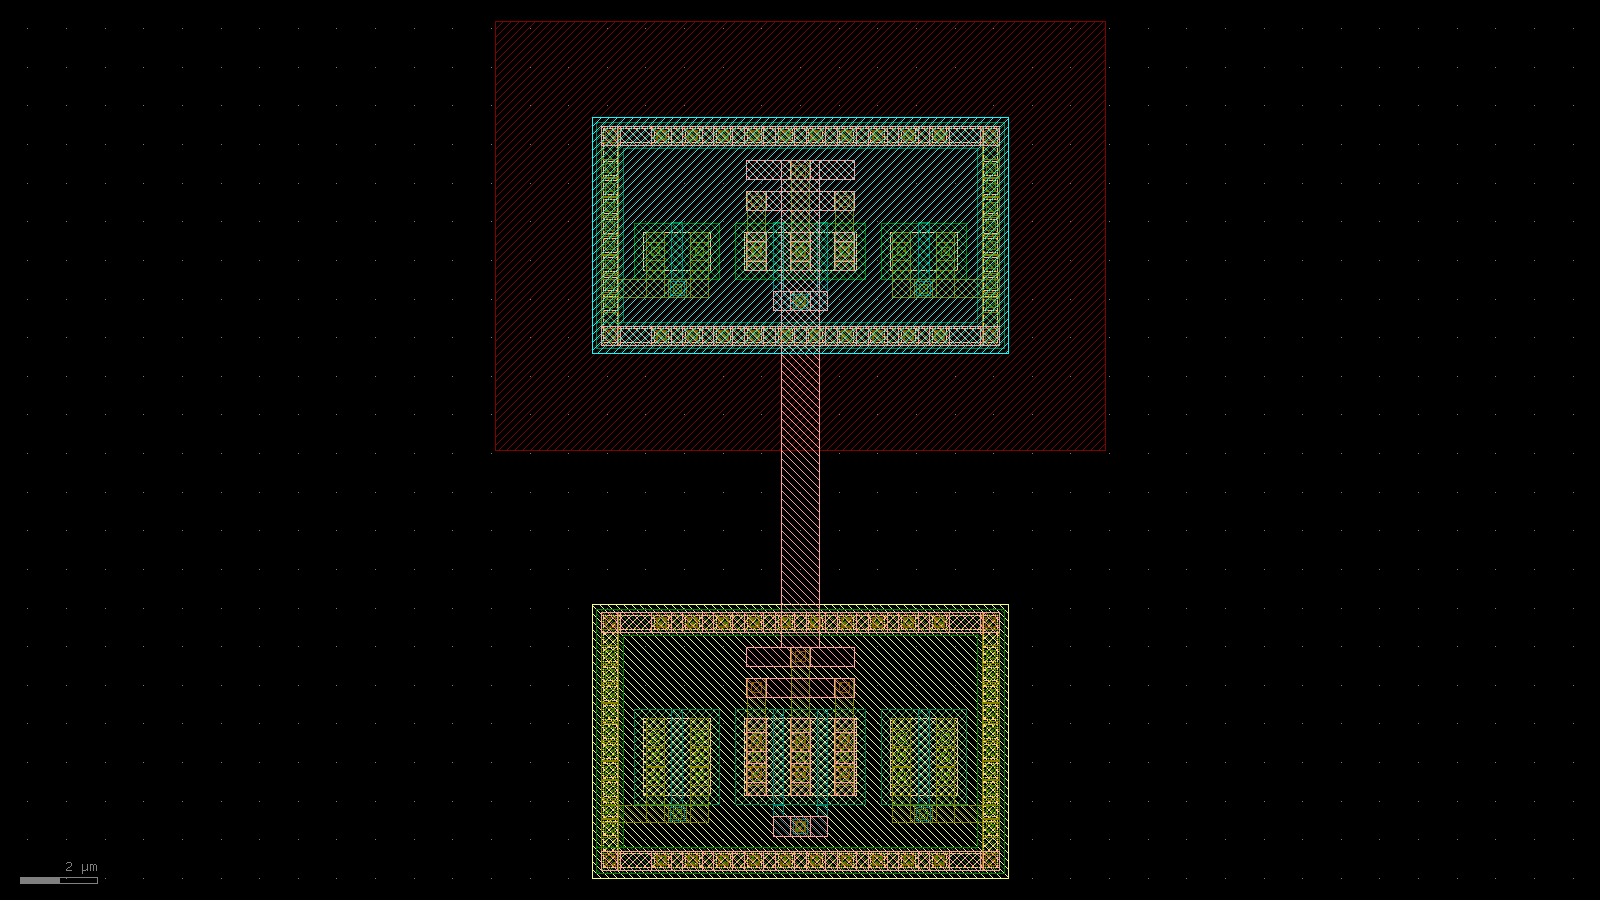

2026-05-20 16:12:42.945 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/inv_wp4.gds'


wp=4 wn=2


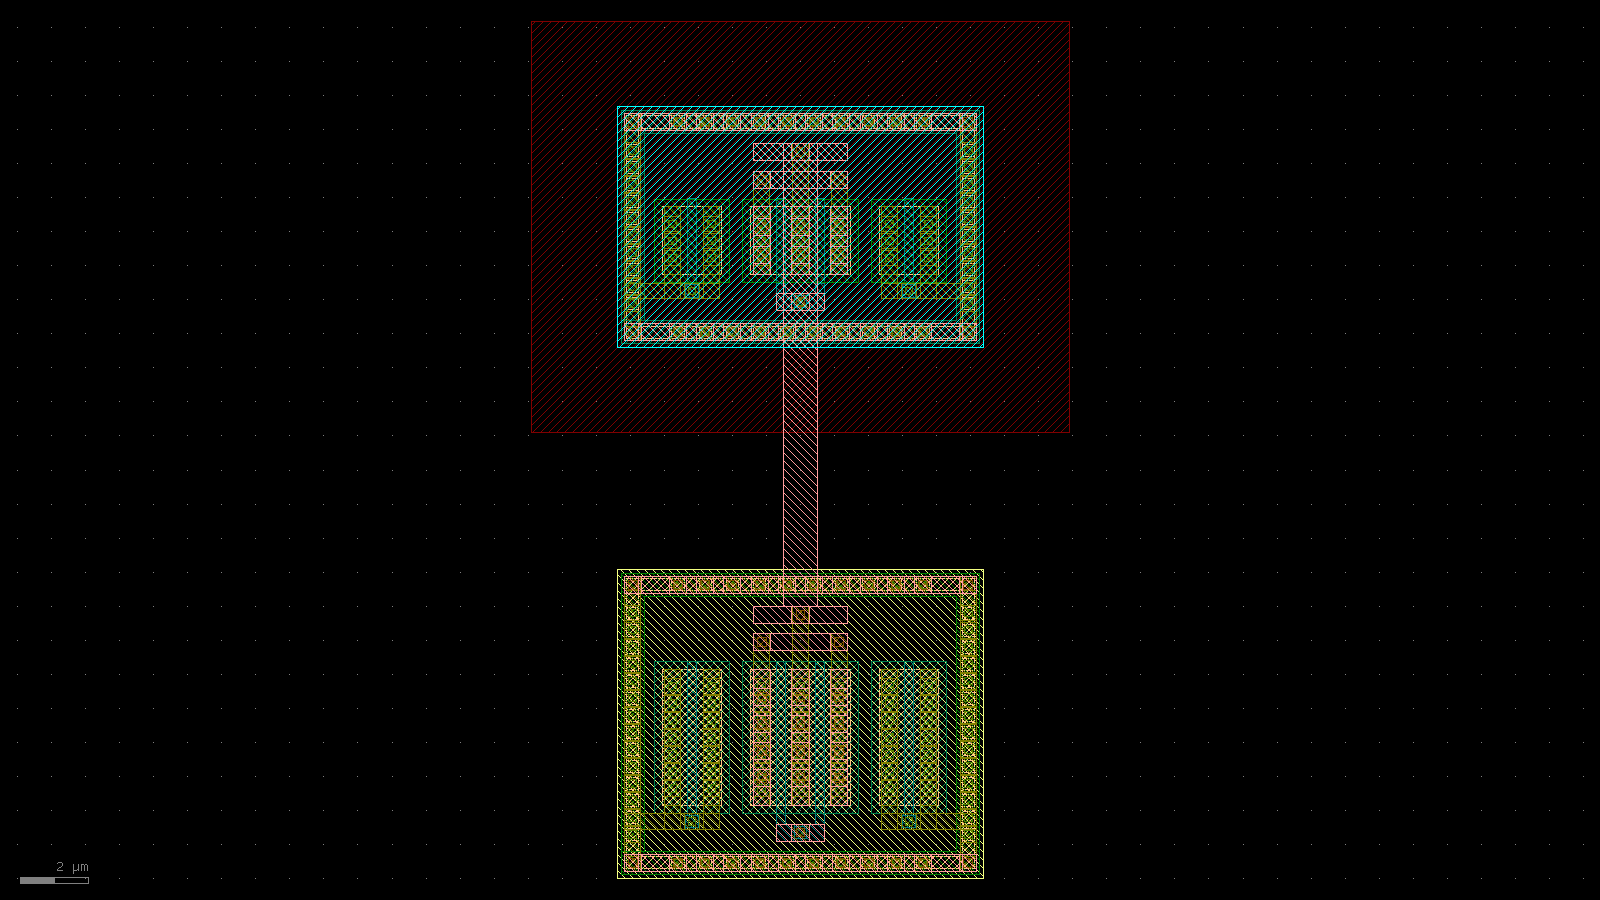

2026-05-20 16:12:45.718 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/inv_wp8.gds'


wp=8 wn=4


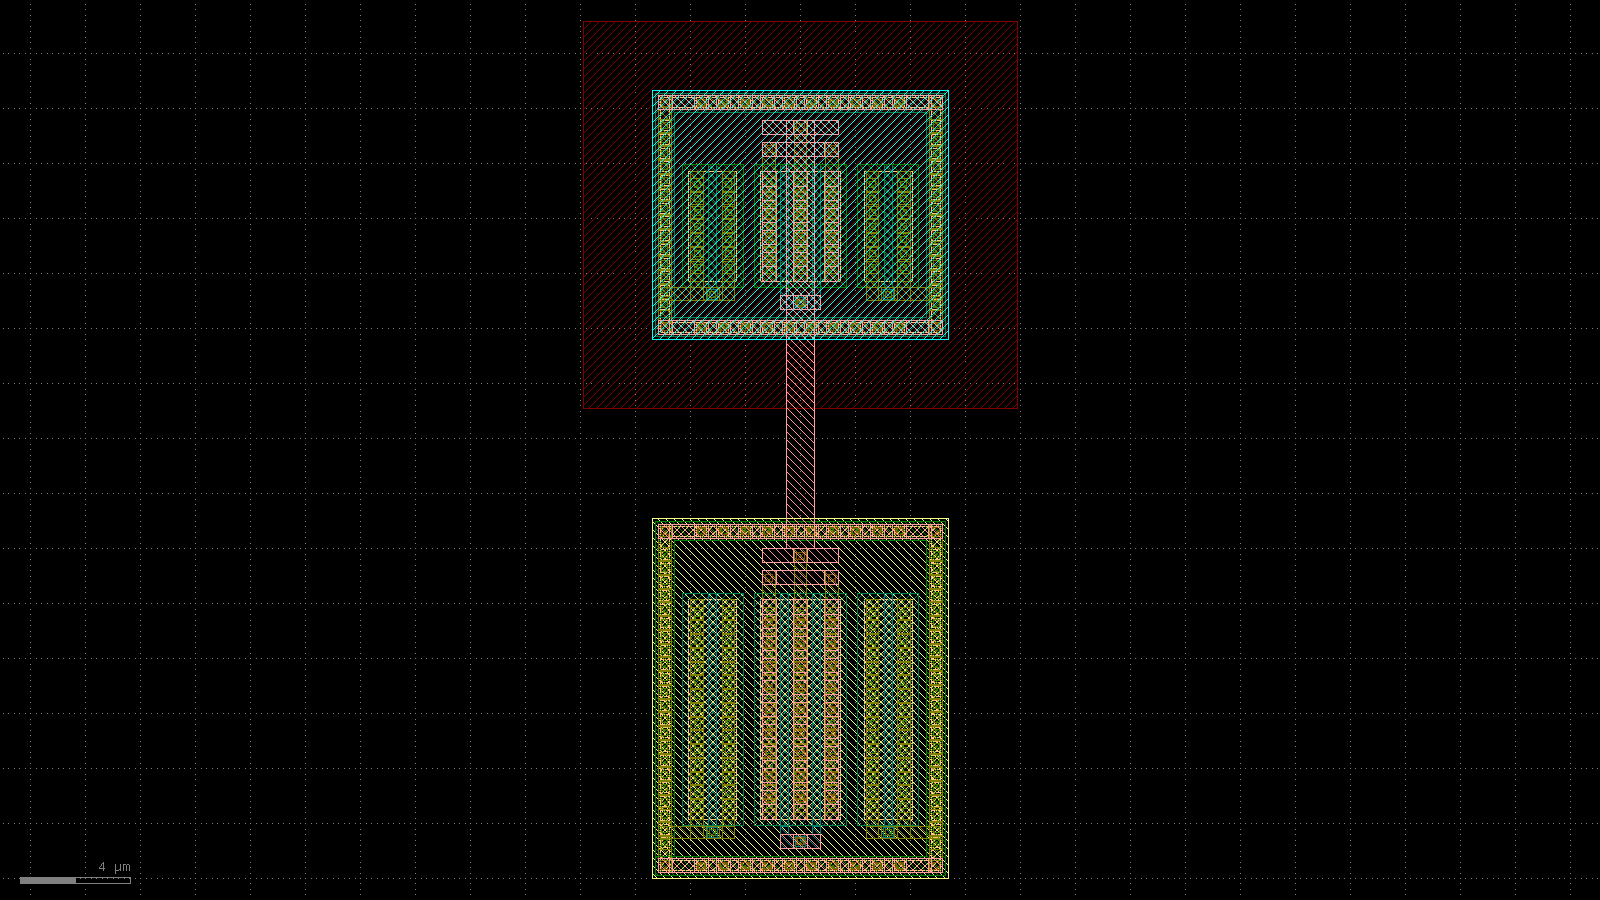

In [5]:
for wp, wn in [(2, 1), (4, 2), (8, 4)]:
    c = Inverter(wp=wp, wn=wn).build(name=f'inv_wp{wp}')
    print(f'wp={wp} wn={wn}')
    c.show()